# HMM State Selection: Standard (Batch) Training
#### with the [glhmm toolbox](https://github.com/vidaurre/glhmm)

This notebook walks through a principled workflow for choosing how many hidden states (K)
to use when fitting an HMM to neuroimaging data using **standard (full-batch) EM training**.
All data are held in memory; the EM algorithm updates model parameters using the complete
dataset on every cycle. This is the simplest approach and works well for small-to-medium
datasets.

For large datasets that do not fit in RAM see
**[HMM_state_selection_stochastic](HMM_state_selection_stochastic.ipynb)**
(stochastic mini-batch training).

We evaluate two complementary criteria:
- **Stability (Gamma similarity):** how reproducible is the state solution across independent
  random initialisations? High and consistent similarity → well-identified solution.
- **Model fit (free energy):** how well does the model explain the data? Lower is better;
  look for an elbow where gains flatten off.

> ⚠️ K must be chosen **before** any downstream analysis (e.g., phenotype prediction).
> Choosing K based on prediction accuracy inflates results due to implicit test-set leakage.

**Reference:** Vidaurre et al. (2023), *glhmm: a Python toolbox for generalised linear hidden
Markov modelling*, [GitHub](https://github.com/vidaurre/glhmm)


### Objective

> **Research question:** What number of hidden states (K) best captures the structure
> in my neuroimaging data?

### Dataset

This demo uses a small synthetic dataset (`data_sim.npy`) that can be downloaded
automatically in the next cell. The dataset was originally created by **Christine Ahrends** as part of the
glhmm prediction tutorial — see
[Prediction_tutorial.ipynb](https://github.com/vidaurre/glhmm/blob/main/docs/notebooks/Prediction_tutorial.ipynb).

Replace `PATH_DATA` / `FILE_NAME` with your own data when applying this to real data.

Expected data format: NumPy array of shape `(n_timepoints, n_subjects, n_features)`.

Authors: Nick Yao Larsen <nylarsen@cfin.au.dk>

## Table of Contents

- [Part 1 - Data Preparation](#part1)
  - [Step 1 - Load data](#step1)
  - [Step 2 - Preprocess](#step2)
  - [Step 3 - Configure training settings](#step3)
- [Part 2 - Standard Batch HMM Training](#part2)
  - [Step 4 - Train HMMs](#step4)
  - [Load saved results](#load)
- [Part 3 - Model Selection](#part3)
  - [Step 5 - Visualise stability and model fit](#step5)
  - [Step 6 - Choose K](#step6)


### Import libraries

In [4]:
# Install the GLHMM_package when using Google Colab
try:
    import google.colab
    IN_COLAB = True
    !pip install -q git+https://github.com/vidaurre/glhmm
except ImportError:
    IN_COLAB = False

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from glhmm import glhmm, preproc, utils, statistics, graphics



### Download demo data

The cell below checks whether the demo dataset is already present in the `data/`
folder and downloads it from OSF automatically if not. **Skip this cell if you are
using your own data** => point `PATH_DATA` at your data folder in Step 1 instead.


In [ ]:
utils.osf_download_data('https://osf.io/8qcyj/', folder='Simulation_data_numpy')

Files already present in data/.


## Part 1 - Data Preparation <a id='part1'></a>


### Step 1. Load data <a id='step1'></a>

The demo dataset contains 100 synthetic subjects, each with 4800 time points and 50 features.

To use your own data, replace `PATH_DATA` and `FILE_NAME` and ensure the array has shape
`(n_timepoints, n_subjects, n_features)` with equal timepoints across subjects.

Also, the demonstration includes the indices that belong to each subject and is stored in `idx_data`.

In [12]:
# ── User settings ─────────────────────────────────────────────────────────
PATH_DATA = Path('data')          # folder containing demo_data.npy
FILE_NAME = 'data_sim.npy'
# ──────────────────────────────────────────────────────────────────────────

Y = np.load(PATH_DATA / FILE_NAME)
idx_data = np.load(PATH_DATA / 'idx_data.npy')
n_timepoints, n_subjects, n_features = Y.shape

print(f'Data shape : {Y.shape}')
print(f'  Timepoints per subject : {n_timepoints}')
print(f'  Subjects               : {n_subjects}')
print(f'  Features               : {n_features}')

print(f'Index of data samples :\n {idx_data[:3]}\n ...\n{idx_data[-3:]}')

Data shape : (4800, 100, 50)
  Timepoints per subject : 4800
  Subjects               : 100
  Features               : 50
Index of data samples :
 [[    0  4800]
 [ 4800  9600]
 [ 9600 14400]]
 ...
[[465600 470400]
 [470400 475200]
 [475200 480000]]


### Step 2. Preprocess data <a id='step2'></a>

Reshape the 3-D array to 2-D (subjects concatenated along the time axis), build a subject
index array, then call `preproc.preprocess_data()` to standardise each subject's time series.


In [ ]:
# Reshape (n_timepoints, n_subjects, n_features) -> (n_subjects * n_timepoints, n_features)
# Be careful with this step when using real data 
# this function assumes the the length for each subject is the same, and that the data are ordered by subject 
# (i.e. all timepoints for subject 1, then all timepoints for subject 2, etc.). 
# If this is not the case, you will need to reshape the data manually and adjust the index array accordingly.

Y_2d = statistics.get_concatenate_subjects(Y) 

Y_preproc, idx_preproc, log_preproc = preproc.preprocess_data(Y_2d, idx_data, standardise=True)

print(f'Preprocessed shape : {Y_preproc.shape}')
print(f'Index array shape  : {idx_preproc.shape}')


Preprocessed shape : (480000, 50)
Index array shape  : (100, 2)


### Step 3. Configure training settings <a id='step3'></a>

For the demo we test K = 3 to 8 with 5 repetitions each.

For real data use a wider range (e.g. 5-12) and more repetitions (10).


In [ ]:
# ── Model settings ───────────────────────────────────────────────────────
COVTYPE    = 'full'   # 'full' | 'diag' | 'shareddiag' | 'sharedfull'
MODEL_MEAN = 'no'     # 'no' (standardised data) | 'state' (raw activation levels)
# ──────────────────────────────────────────────────────────────────────────
state_range = range(3, 9)    # K values to evaluate (3, 4, 5, 6, 7, 8)
n_repeats   = 5              # independent runs per K
SAVE_DIR    = Path.cwd() / 'results_standard'
SAVE_DIR.mkdir(parents=True, exist_ok=True)

print(f'K values    : {list(state_range)}')
print(f'Repetitions : {n_repeats}')
print(f'Results dir : {SAVE_DIR}')


K values    : [3, 4, 5, 6, 7, 8]
Repetitions : 5
Results dir : c:\Users\au323479\Github\glhmm_protocols\Procedures\results_standard


## Part 2 - Standard Batch HMM Training <a id='part2'></a>

For each K value and each random seed we:
1. Initialise an HMM with `covtype='full'` (one full covariance matrix per state).
2. Train using full-batch EM until convergence or `cyc` cycles.
3. Compute Gamma similarity between rep 0 (reference) and all subsequent reps to measure
   how reproducible the state solution is.
4. Save each model immediately to protect against interruptions.


### Step 4. Train HMMs <a id='step4'></a>

Key model settings (set in the cell above):

| Parameter | Default | When to change |
|-----------|---------|----------------|
| `COVTYPE` | `'full'` | Use `'diag'` for speed with many features; `'sharedfull'` for one shared FC matrix |
| `MODEL_MEAN` | `'no'` | Change to `'state'` if data are **not** mean-centred and activation levels carry information |

**Why `covtype='full'`?**
Each state gets its own full covariance matrix over all features. For neuroimaging data
this means each state captures a distinct functional connectivity (FC) pattern. This is
the richest parameterisation and the most informative for downstream prediction (e.g.
the Fisher kernel uses these per-state covariances). Cheaper alternatives drop
off-diagonal correlations (`'diag'`) or share one FC matrix across all states
(`'sharedfull'`), both of which lose state-specific connectivity structure.

**Why `model_mean='no'`?**
Standard fMRI preprocessing (z-scoring, normalisation) removes the session mean, so
there is no per-state activation level to estimate. Fitting means on already-demeaned
data adds free parameters that carry no signal and can slow convergence. Change to
`'state'` only if your data retains meaningful absolute activation differences between
brain states.

Training options (`cyc`, `min_cyc`, `verbose`) are passed via the `options` dict below.


In [ ]:
# ── Training options ──────────────────────────────────────────────────────
# ⚠️  Demo values — for real data use higher
options = {
    'cyc':     100,   # demo only — increase for real data
    'min_cyc': 10,    # demo only
    'verbose': False,
}
# ──────────────────────────────────────────────────────────────────────────

results = utils.run_stability_training(
    Y_preproc, idx_data, state_range, n_repeats, SAVE_DIR,
    log_preproc=log_preproc,
    covtype=COVTYPE,
    model_mean=MODEL_MEAN,
    options=options,
)

Training HMM with 3 states (5 repetitions)...
  K=3  rep=1/5  FE=32113039.84
  K=3  rep=2/5  FE=32147137.56
  K=3  rep=3/5  FE=32100085.75
  K=3  rep=4/5  FE=32114057.01
  K=3  rep=5/5  FE=32118845.01
Training HMM with 4 states (5 repetitions)...
  K=4  rep=1/5  FE=32028784.11
  K=4  rep=2/5  FE=32024982.29
  K=4  rep=3/5  FE=32028470.44
  K=4  rep=4/5  FE=32051202.39
  K=4  rep=5/5  FE=32023419.20
Training HMM with 5 states (5 repetitions)...
  K=5  rep=1/5  FE=31918623.42
  K=5  rep=2/5  FE=31930837.39
  K=5  rep=3/5  FE=31985508.81
  K=5  rep=4/5  FE=31916911.72
  K=5  rep=5/5  FE=31983111.69
Training HMM with 6 states (5 repetitions)...
  K=6  rep=1/5  FE=31953025.09
  K=6  rep=2/5  FE=31947138.69
  K=6  rep=3/5  FE=31880973.84
  K=6  rep=4/5  FE=31879241.51
  K=6  rep=5/5  FE=31943364.32
Training HMM with 7 states (5 repetitions)...
  K=7  rep=1/5  FE=31924344.57
  K=7  rep=2/5  FE=31844337.07
  K=7  rep=3/5  FE=31924892.02
  K=7  rep=4/5  FE=31849959.33
  K=7  rep=5/5  FE=3184556

### Load saved results <a id='load'></a>

Run this cell **instead of the training cell above** if results already exist.

- **Case A:** `summary_results.pkl` present -> loads directly.
- **Case B:** Only individual `hmm_K*_rep*.pkl` files -> rebuilds the summary.


In [9]:
results, state_range = utils.load_stability_results(SAVE_DIR)

Loaded summary_results.pkl  (K = [3, 4, 5, 6, 7, 8])

    K | N reps | N sim scores |   Min final FE
--------------------------------------------
   3 |      5 |            4 |    32100085.75
   4 |      5 |            4 |    32023419.20
   5 |      5 |            4 |    31916911.72
   6 |      5 |            4 |    31879241.51
   7 |      5 |            4 |    31844337.07
   8 |      5 |            4 |    31818622.52


## Part 3 - Model Selection <a id='part3'></a>


### Step 5. Visualise stability and model fit <a id='step5'></a>

Three panels:

1. **Gamma Similarity (violin)** — distribution of pairwise similarity scores across
   repetitions per K. High mean (red line) and narrow spread = stable solution.
   Grey dashed line: 0.8 minimum-stability threshold.

2. **Free Energy Elbow** — normalised minimum free energy vs K. Lower = better fit.
   Auto-detected elbow (grey dashed line) marks diminishing returns.

3. **Convergence Curves** — free energy across EM cycles for the best repetition per K.
   Curves should plateau; a still-descending curve means `cyc` needs to increase.


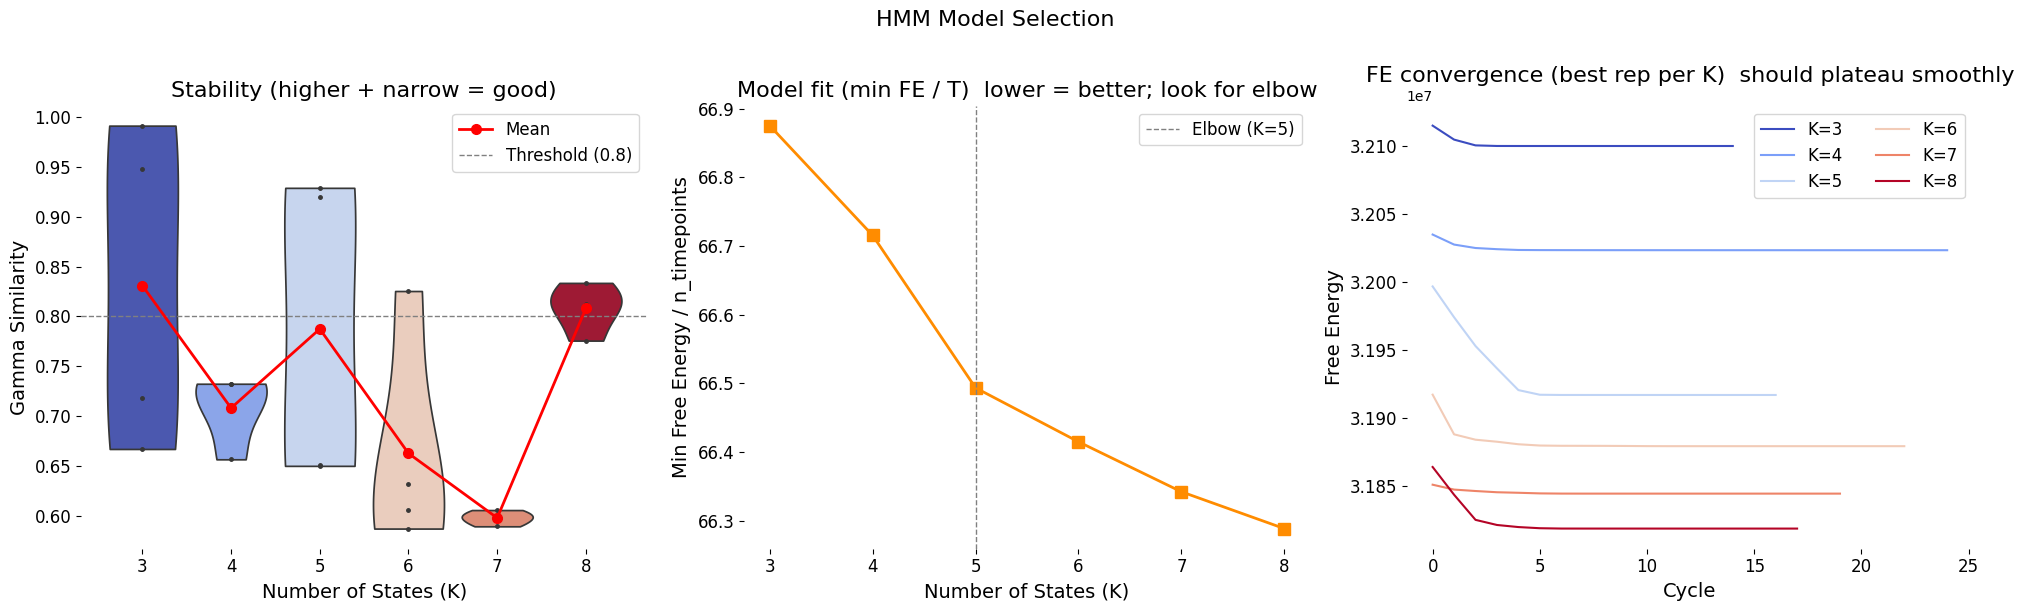

    K |  Mean Sim |  Std Sim |   Min FE/T | Converged?
----------------------------------------------------
   3 |    0.8309 |   0.1405 |      66.88 |        yes
   4 |    0.7081 |   0.0309 |      66.72 |        yes
   5 |    0.7874 |   0.1367 |      66.49 |        yes
   6 |    0.6626 |   0.0954 |      66.42 |        yes
   7 |    0.5979 |   0.0059 |      66.34 |        yes
   8 |    0.8082 |   0.0208 |      66.29 |        yes


In [10]:
avg_similarity, min_fe = graphics.plot_model_selection(
    results, Y_preproc.shape[0],
    save_path=str(SAVE_DIR / 'model_selection.png'),
)

### Step 6. Choose K <a id='step6'></a>

Read the two panels together:

- **Stability first:** discount any K where mean Gamma similarity < 0.8 or the violin
  is very wide. An unstable K means the optimiser finds qualitatively different solutions
  across random initialisations.

- **Free energy elbow:** among stable K values, prefer the one at or just before the elbow.
  Gains beyond the elbow are small; additional states add complexity without explanatory power.

- **Convergence:** `CHECK` in the table means the best run had not fully converged;
  increase `cyc` or `min_cyc` before trusting that K's metrics.

#### When the two criteria disagree

It is common for stability and free energy to point to different K values. For example:

- The **elbow** is at K=5 because the biggest single drop in free energy occurs at K=4→K=5.
  This is the point of diminishing returns: adding more states beyond K=5 keeps improving
  the fit, but by a shrinking amount.

- A **higher K** (e.g. K=8) might still pass the stability threshold and have an even
  tighter violin. Hence, the optimiser reliably converges to the same solution. Lower
  free energy at K=8 also means it explains the data better.

In that case both K values are defensible. A few considerations for choosing between them:

| Consideration | Prefer lower K (elbow) | Prefer higher K |
|---------------|------------------------|-----------------|
| Parsimony | Simpler model, fewer parameters to estimate | — |
| Fragmentation risk | — | Higher K may split one true state into two near-identical states, especially with limited data or short training |
| Prediction goal | — | More states can capture finer individual differences; test with `prediction.predict_phenotype()` |
| Data size | Small dataset → higher K overfits | Large dataset → higher K is more feasible |

> **Practical rule:** if a higher K passes stability *and* has a clearly tighter violin
> than the elbow K, run `prediction.predict_phenotype()` for both and pick the winner. If prediction
> accuracy is similar, prefer the lower K for parsimony.

> **Note on demo data:** the simulated dataset used here is small (100 subjects, 25 cycles).
> Results can shift noticeably with more repetitions or longer training. Treat the demo
> output as illustrative, not definitive.

Set `CHOSEN_K` below. **Do not change it after inspecting any downstream results.**


In [11]:
CHOSEN_K = 5   # <- set after inspecting plots, e.g. CHOSEN_K = 5

if CHOSEN_K is None:
    raise ValueError('Set CHOSEN_K based on the stability and free energy plots above.')

best_rep = int(np.argmin([fe[-1] for fe in results[CHOSEN_K]['FE']]))
print(f'Chosen K = {CHOSEN_K}')
print(f'Best repetition: {best_rep + 1}  (lowest final free energy)')
print(f'Mean stability : {avg_similarity[CHOSEN_K]:.4f}')
print(f'Min FE/T       : {min_fe[CHOSEN_K]:.4f}')


Chosen K = 5
Best repetition: 4  (lowest final free energy)
Mean stability : 0.7874
Min FE/T       : 66.4936
